# Notebook 1 — Base Model: Modified EEGNet

**EEG-based Parkinson's Disease Detection using Modified EEGNet**

- **Dataset**: OpenNeuro ds004584 (preprocessed)
- **Input**: Preprocessed EEG epochs shaped `(N, C, T)` where:
  - N = number of epochs
  - C = number of channels (common channels across subjects)
  - T = 500 samples (2s × 250Hz)
- **Output**: Binary classification `PD vs Control`
- **Data Split**: Subject-wise (70% train, 15% val, 15% test)

> **Note**: Data is pre-split by subject in preprocessing to prevent data leakage.

In [2]:
# ===== Imports =====
import os
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Optional: EEG preprocessing (use if you load raw EEG here)
# import mne

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Using device: cuda


In [3]:
# ===== Config =====
@dataclass
class Config:
    # Data paths (relative to this notebook in models/ folder)
    data_dir: str = "../data/processed/ds004584"
    
    # Model parameters (will be set dynamically after loading data)
    n_channels: int = 63      # Will be updated based on actual data
    n_classes: int = 2        # Binary: PD (1) vs Control (0)
    sampling_rate: int = 250  # From preprocessing
    epoch_seconds: float = 2.0
    n_samples: int = 500      # 2s × 250Hz

    # Model architecture (REDUCED capacity to prevent overfitting)
    F1: int = 4               # Reduced from 8 → 4 temporal filters
    D: int = 2                # Depth multiplier
    F2: int = 8               # Reduced from 16 → 8 pointwise filters
    dropout: float = 0.6      # Increased from 0.5 → 0.6 for regularization

    # Training hyperparameters
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 5e-4  # Increased from 1e-4 for stronger regularization
    epochs: int = 40
    patience: int = 10        # Early stopping patience
    
    # Data augmentation (for training only)
    use_augmentation: bool = True
    noise_std: float = 0.1    # Gaussian noise standard deviation
    time_mask_ratio: float = 0.1  # Fraction of time to mask

cfg = Config()
print(f"Data directory: {cfg.data_dir}")
print(f"Model: F1={cfg.F1}, D={cfg.D}, F2={cfg.F2}, dropout={cfg.dropout}")
print(f"Weight decay: {cfg.weight_decay}, Augmentation: {cfg.use_augmentation}")

Data directory: ../data/processed/ds004584
Model: F1=4, D=2, F2=8, dropout=0.6
Weight decay: 0.0005, Augmentation: True


## Data Loading

The preprocessing notebook (`preprocessing/preprocess_ds004584.ipynb`) creates:
- `train.npz`, `val.npz`, `test.npz` - Subject-wise split data
- `norm_params.npz` - Normalization parameters
- `channels.json` - Channel names used

Each `.npz` file contains:
- `X`: float32 array `(N, C, T)` - Normalized EEG epochs
- `y`: int labels `(N,)` - 0=Control, 1=PD
- `subject_id`: `(N,)` - Subject ID for each epoch

In [4]:
# ===== Load preprocessed data =====
def load_split(data_dir: str, split: str):
    """Load a data split (train/val/test) from .npz file."""
    path = Path(data_dir) / f"{split}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Expected preprocessed data at {path}.\n"
            "Run preprocessing/preprocess_ds004584.ipynb first to generate the data."
        )
    data = np.load(path, allow_pickle=True)
    X = data["X"].astype(np.float32)  # (N, C, T)
    y = data["y"].astype(np.int64)    # (N,)
    subject_id = data["subject_id"] if "subject_id" in data.files else None
    return X, y, subject_id

# Load all splits
print("Loading preprocessed data...")
X_train, y_train, sid_train = load_split(cfg.data_dir, "train")
X_val, y_val, sid_val = load_split(cfg.data_dir, "val")
X_test, y_test, sid_test = load_split(cfg.data_dir, "test")

# Update config with actual dimensions
cfg.n_channels = X_train.shape[1]
cfg.n_samples = X_train.shape[2]

print(f"\n{'='*50}")
print("DATASET LOADED")
print(f"{'='*50}")
print(f"Train: {X_train.shape} | PD: {(y_train==1).sum()}, Control: {(y_train==0).sum()}")
print(f"Val:   {X_val.shape} | PD: {(y_val==1).sum()}, Control: {(y_val==0).sum()}")
print(f"Test:  {X_test.shape} | PD: {(y_test==1).sum()}, Control: {(y_test==0).sum()}")
print(f"\nChannels: {cfg.n_channels}, Samples: {cfg.n_samples}")

Loading preprocessed data...

DATASET LOADED
Train: (16255, 60, 500) | PD: 10576, Control: 5679
Val:   (3668, 60, 500) | PD: 2429, Control: 1239
Test:  (3767, 60, 500) | PD: 2432, Control: 1335

Channels: 60, Samples: 500


In [5]:
# ===== EEG Data Augmentation =====
class EEGAugmentation:
    """
    EEG-specific data augmentation to improve generalization.
    Applied only during training.
    """
    def __init__(self, noise_std=0.1, time_mask_ratio=0.1):
        self.noise_std = noise_std
        self.time_mask_ratio = time_mask_ratio
    
    def add_gaussian_noise(self, x):
        """Add Gaussian noise to EEG signal."""
        noise = torch.randn_like(x) * self.noise_std
        return x + noise
    
    def time_masking(self, x):
        """Randomly mask a portion of time samples (set to zero)."""
        T = x.shape[-1]
        mask_len = int(T * self.time_mask_ratio)
        if mask_len > 0:
            start = torch.randint(0, T - mask_len, (1,)).item()
            x[..., start:start + mask_len] = 0
        return x
    
    def __call__(self, x):
        """Apply random augmentations."""
        if torch.rand(1).item() < 0.5:
            x = self.add_gaussian_noise(x)
        if torch.rand(1).item() < 0.5:
            x = self.time_masking(x.clone())
        return x


# ===== PyTorch Dataset with Augmentation =====
class EEGDataset(Dataset):
    """PyTorch Dataset for EEG epochs with optional augmentation."""
    def __init__(self, X, y, subject_ids=None, augment=False, aug_config=None):
        self.X = torch.from_numpy(X)  # (N, C, T)
        self.y = torch.from_numpy(y)  # (N,)
        self.subject_ids = subject_ids  # Keep for subject-level evaluation
        self.augment = augment
        self.augmenter = EEGAugmentation(
            noise_std=aug_config.noise_std if aug_config else 0.1,
            time_mask_ratio=aug_config.time_mask_ratio if aug_config else 0.1
        ) if augment else None
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment and self.augmenter:
            x = self.augmenter(x)
        return x, self.y[idx]

# Create datasets (with augmentation for training only)
train_dataset = EEGDataset(X_train, y_train, sid_train, 
                           augment=cfg.use_augmentation, aug_config=cfg)
val_dataset = EEGDataset(X_val, y_val, sid_val, augment=False)
test_dataset = EEGDataset(X_test, y_test, sid_test, augment=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} (with augmentation: {cfg.use_augmentation})")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 254 (with augmentation: True)
Val batches: 58
Test batches: 59


## Model: Modified EEGNet

EEGNet uses **depthwise + separable convolutions** (very lightweight) and is popular for EEG classification.

You can tune:
- temporal kernel length
- depth multiplier
- number of filters
- dropout


In [6]:
# ===== Modified EEGNet (PyTorch) =====
class SeparableConv2d(nn.Module):
    """Depthwise separable convolution: depthwise -> pointwise."""
    def __init__(self, in_ch, out_ch, kernel_size, padding=(0,0), bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size=kernel_size, 
                                   padding=padding, groups=in_ch, bias=bias)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=(1,1), bias=bias)
    
    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class EEGNetModified(nn.Module):
    """
    Modified EEGNet for EEG classification (lightweight version).
    
    Architecture:
    1. Temporal convolution (learns frequency filters)
    2. Depthwise convolution (learns spatial filters per channel)
    3. Separable convolution (combines temporal-spatial features)
    4. Classifier head
    
    Args:
        n_channels: Number of EEG channels
        n_classes: Number of output classes
        T: Number of time samples per epoch
        F1: Number of temporal filters (reduced for regularization)
        D: Depth multiplier for depthwise conv
        F2: Number of pointwise filters (reduced for regularization)
        kern_len: Temporal kernel length (related to sampling rate)
        dropout: Dropout probability (increased for regularization)
    """
    def __init__(self, n_channels, n_classes, T, F1=4, D=2, F2=8, kern_len=64, dropout=0.6):
        super().__init__()
        
        # Store config for reference
        self.config = {'F1': F1, 'D': D, 'F2': F2, 'dropout': dropout}
        
        # Block 1: Temporal convolution
        # Input: (B, 1, C, T) -> learns F1 frequency filters
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1)
        )
        
        # Block 2: Depthwise convolution across channels
        # Learns D spatial filters per temporal filter
        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )
        
        # Block 3: Separable convolution for temporal refinement
        self.separable_conv = nn.Sequential(
            SeparableConv2d(F1*D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )
        
        # Compute flattened feature dimension
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, T)
            out = self.separable_conv(self.depthwise_conv(self.temporal_conv(dummy)))
            self.feat_dim = out.view(1, -1).shape[1]
        
        # Classifier head
        self.classifier = nn.Linear(self.feat_dim, n_classes)
        
        # Confidence head (for error-correction stage)
        self.conf_head = nn.Linear(self.feat_dim, 1)

    def forward(self, x, return_features=False):
        """
        Forward pass.
        
        Args:
            x: Input tensor (B, C, T)
            return_features: If True, also return intermediate features
            
        Returns:
            logits: Class logits (B, n_classes)
            conf: Confidence score (B, 1) - only if return_features=True
            feats: Flattened features (B, feat_dim) - only if return_features=True
        """
        x = x.unsqueeze(1)  # (B, C, T) -> (B, 1, C, T)
        x = self.temporal_conv(x)
        x = self.depthwise_conv(x)
        x = self.separable_conv(x)
        feats = x.flatten(1)
        
        logits = self.classifier(feats)
        
        if return_features:
            conf = torch.sigmoid(self.conf_head(feats))
            return logits, conf, feats
        return logits


# Create model with reduced capacity
model = EEGNetModified(
    n_channels=cfg.n_channels,
    n_classes=cfg.n_classes,
    T=cfg.n_samples,
    F1=cfg.F1,      # Reduced: 4 (was 8)
    D=cfg.D,        # Keep: 2
    F2=cfg.F2,      # Reduced: 8 (was 16)
    dropout=cfg.dropout  # Increased: 0.6 (was 0.5)
).to(DEVICE)

# Print model summary
print(f"Model: EEGNetModified (Lightweight)")
print(f"Architecture: F1={cfg.F1}, D={cfg.D}, F2={cfg.F2}, dropout={cfg.dropout}")
print(f"Input shape: ({cfg.batch_size}, {cfg.n_channels}, {cfg.n_samples})")
print(f"Feature dimension: {model.feat_dim}")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: EEGNetModified (Lightweight)
Architecture: F1=4, D=2, F2=8, dropout=0.6
Input shape: (64, 60, 500)
Feature dimension: 120
Total parameters: 1,331
Trainable parameters: 1,331


In [7]:
# ===== Training & Evaluation utilities =====
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(1, len(loader))

def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.append(yb.numpy())
            y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm, y_true, y_pred


# ===== Class weights to handle imbalance =====
def compute_class_weights(y):
    """Compute inverse frequency class weights."""
    classes, counts = np.unique(y, return_counts=True)
    weights = len(y) / (len(classes) * counts)
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(y_train).to(DEVICE)
print(f"Class weights: Control={class_weights[0]:.3f}, PD={class_weights[1]:.3f}")

Class weights: Control=1.431, PD=0.768


## Training Loop

Training with:
- **Optimizer**: AdamW with weight decay
- **Loss**: Cross-entropy
- **Early stopping**: Based on validation F1 score
- **Best model**: Saved based on validation performance

Note: Data is already split by subject in preprocessing (no CV needed here).

In [8]:
# ===== Training Loop with Improvements =====
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.CrossEntropyLoss(weight=class_weights)  # Class-weighted loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training history
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
}

best_val_f1 = -1
best_model_state = None
best_epoch = 0  # Track best epoch explicitly
patience_counter = 0

print("=" * 60)
print("TRAINING STARTED")
print(f"Improvements: Dropout={cfg.dropout}, F1={cfg.F1}, F2={cfg.F2}")
print(f"Weight decay={cfg.weight_decay}, Augmentation={cfg.use_augmentation}")
print(f"Class weights: {class_weights.cpu().numpy()}")
print("=" * 60)

for epoch in range(1, cfg.epochs + 1):
    # === Training ===
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []
    
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(yb.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds)
    
    # === Validation ===
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            
            val_loss += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Update learning rate scheduler
    scheduler.step(val_f1)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Check for best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch  # Log best epoch explicitly
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = " *** BEST ***"
    else:
        patience_counter += 1
        marker = ""
    
    # Print progress
    print(f"Epoch {epoch:03d} | LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}{marker}")
    
    # Early stopping
    if patience_counter >= cfg.patience:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {cfg.patience} epochs)")
        break

print(f"\n{'='*60}")
print(f"Training complete! Best Val F1: {best_val_f1:.4f} at Epoch {best_epoch}")
print(f"{'='*60}")

c:\Users\MSI\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING STARTED
Improvements: Dropout=0.6, F1=4, F2=8
Weight decay=0.0005, Augmentation=True
Class weights: [1.4311498  0.76848525]
Epoch 001 | LR: 1.00e-03 | Train Loss: 0.6510, Acc: 0.6010, F1: 0.6571 | Val Loss: 0.6168, Acc: 0.6677, F1: 0.7004 *** BEST ***
Epoch 002 | LR: 1.00e-03 | Train Loss: 0.5634, Acc: 0.6759, F1: 0.7066 | Val Loss: 0.6930, Acc: 0.5856, F1: 0.5674
Epoch 003 | LR: 1.00e-03 | Train Loss: 0.4789, Acc: 0.7443, F1: 0.7793 | Val Loss: 0.8746, Acc: 0.5294, F1: 0.4804
Epoch 004 | LR: 1.00e-03 | Train Loss: 0.4062, Acc: 0.8017, F1: 0.8357 | Val Loss: 0.8449, Acc: 0.6508, F1: 0.6798
Epoch 005 | LR: 1.00e-03 | Train Loss: 0.3552, Acc: 0.8314, F1: 0.8623 | Val Loss: 0.9439, Acc: 0.6739, F1: 0.7118 *** BEST ***
Epoch 006 | LR: 1.00e-03 | Train Loss: 0.3359, Acc: 0.8484, F1: 0.8777 | Val Loss: 1.0608, Acc: 0.6573, F1: 0.6932
Epoch 007 | LR: 1.00e-03 | Train Loss: 0.3151, Acc: 0.8574, F1: 0.8846 | Val Loss: 1.1349, Acc: 0.6559, F1: 0.6934
Epoch 008 | LR: 1.00e-03 | Train Los

## Evaluation on Test Set

Load the best model and evaluate on the held-out test set.

In [9]:
# ===== Threshold Tuning on Validation Set =====
def find_optimal_threshold(model, loader, metric='f1'):
    """Find optimal classification threshold using validation set."""
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]  # P(PD)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Search for optimal threshold
    best_thresh, best_score = 0.5, 0
    for thresh in np.arange(0.3, 0.7, 0.01):
        preds = (all_probs >= thresh).astype(int)
        if metric == 'f1':
            score = f1_score(all_labels, preds)
        else:  # balanced accuracy
            from sklearn.metrics import balanced_accuracy_score
            score = balanced_accuracy_score(all_labels, preds)
        if score > best_score:
            best_score = score
            best_thresh = thresh
    
    return best_thresh, best_score

# Load best model and find optimal threshold
model.load_state_dict(best_model_state)
model.eval()

optimal_threshold, val_score = find_optimal_threshold(model, val_loader, metric='f1')
print(f"Optimal threshold (from validation): {optimal_threshold:.2f} (Val F1: {val_score:.4f})")

Optimal threshold (from validation): 0.31 (Val F1: 0.7272)


In [10]:
# ===== Window-Level and Subject-Level Evaluation =====

def evaluate_with_threshold(model, loader, threshold=0.5):
    """Evaluate model with custom threshold."""
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= threshold).astype(int)
    
    return all_labels, preds, all_probs


def subject_level_evaluation(labels, preds, probs, subject_ids):
    """Aggregate window predictions to subject-level using majority voting."""
    if subject_ids is None:
        return None, None, None
    
    unique_subjects = np.unique(subject_ids)
    subj_labels, subj_preds, subj_probs = [], [], []
    
    for sid in unique_subjects:
        mask = subject_ids == sid
        # Subject label (should be same for all windows from same subject)
        subj_label = labels[mask][0]
        # Majority voting for prediction
        subj_pred = int(np.mean(preds[mask]) >= 0.5)
        # Average probability
        subj_prob = np.mean(probs[mask])
        
        subj_labels.append(subj_label)
        subj_preds.append(subj_pred)
        subj_probs.append(subj_prob)
    
    return np.array(subj_labels), np.array(subj_preds), np.array(subj_probs)


# === Window-Level Evaluation ===
print("=" * 60)
print("TEST SET EVALUATION - WINDOW LEVEL")
print("=" * 60)

# With default threshold (0.5)
test_labels_default, test_preds_default, test_probs = evaluate_with_threshold(
    model, test_loader, threshold=0.5)
test_acc_default = accuracy_score(test_labels_default, test_preds_default)
test_f1_default = f1_score(test_labels_default, test_preds_default)

print(f"\n[Threshold = 0.50 (default)]")
print(f"Accuracy: {test_acc_default:.4f}")
print(f"F1 Score: {test_f1_default:.4f}")

# With optimized threshold
test_labels, test_preds, _ = evaluate_with_threshold(
    model, test_loader, threshold=optimal_threshold)
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_cm = confusion_matrix(test_labels, test_preds)

print(f"\n[Threshold = {optimal_threshold:.2f} (optimized)]")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"              Control    PD")
print(f"Actual Control   {test_cm[0,0]:5d}  {test_cm[0,1]:5d}")
print(f"       PD        {test_cm[1,0]:5d}  {test_cm[1,1]:5d}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Control', 'PD'], digits=4))


# === Subject-Level Evaluation ===
print("\n" + "=" * 60)
print("TEST SET EVALUATION - SUBJECT LEVEL")
print("=" * 60)

subj_labels, subj_preds, subj_probs = subject_level_evaluation(
    test_labels, test_preds, test_probs, sid_test)

if subj_labels is not None:
    subj_acc = accuracy_score(subj_labels, subj_preds)
    subj_f1 = f1_score(subj_labels, subj_preds)
    subj_cm = confusion_matrix(subj_labels, subj_preds)
    
    print(f"\nNumber of test subjects: {len(subj_labels)}")
    print(f"Subject-Level Accuracy: {subj_acc:.4f}")
    print(f"Subject-Level F1 Score: {subj_f1:.4f}")
    print(f"\nSubject-Level Confusion Matrix:")
    print(f"                 Predicted")
    print(f"              Control    PD")
    print(f"Actual Control   {subj_cm[0,0]:5d}  {subj_cm[0,1]:5d}")
    print(f"       PD        {subj_cm[1,0]:5d}  {subj_cm[1,1]:5d}")
    print(f"\nSubject-Level Classification Report:")
    print(classification_report(subj_labels, subj_preds, target_names=['Control', 'PD'], digits=4))
else:
    print("\nSubject IDs not available in test data. Skipping subject-level evaluation.")

TEST SET EVALUATION - WINDOW LEVEL

[Threshold = 0.50 (default)]
Accuracy: 0.7088
F1 Score: 0.7168

[Threshold = 0.31 (optimized)]
Accuracy: 0.7558
F1 Score: 0.7843

Confusion Matrix:
                 Predicted
              Control    PD
Actual Control    1174    161
       PD          759   1673

Classification Report:
              precision    recall  f1-score   support

     Control     0.6073    0.8794    0.7185      1335
          PD     0.9122    0.6879    0.7843      2432

    accuracy                         0.7558      3767
   macro avg     0.7598    0.7837    0.7514      3767
weighted avg     0.8042    0.7558    0.7610      3767


TEST SET EVALUATION - SUBJECT LEVEL

Number of test subjects: 23
Subject-Level Accuracy: 0.8261
Subject-Level F1 Score: 0.8462

Subject-Level Confusion Matrix:
                 Predicted
              Control    PD
Actual Control       8      0
       PD            4     11

Subject-Level Classification Report:
              precision    recall  f

## Training History Visualization

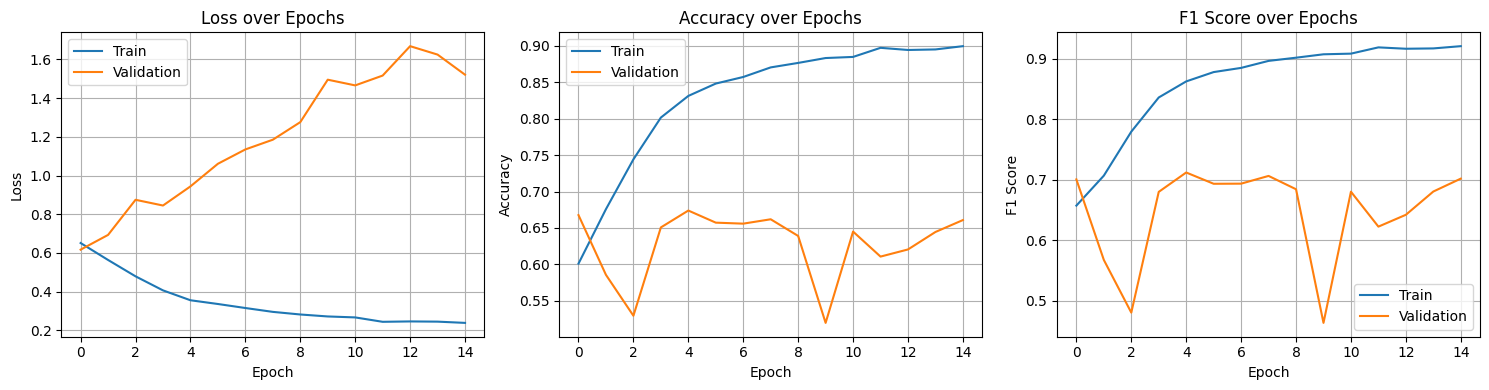

In [11]:
# ===== Plot Training History =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True)

# F1 Score
axes[2].plot(history['train_f1'], label='Train')
axes[2].plot(history['val_f1'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score over Epochs')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Save Model

Save the trained model for later use or error-correction stage.

In [12]:
# ===== Save Model =====
save_dir = Path("../training/saved_models")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "eegnet_modified_parkinsons.pth"
torch.save({
    'model_state_dict': best_model_state,
    'config': {
        'n_channels': cfg.n_channels,
        'n_classes': cfg.n_classes,
        'n_samples': cfg.n_samples,
        'F1': cfg.F1,
        'D': cfg.D,
        'F2': cfg.F2,
        'dropout': cfg.dropout,
    },
    'training_config': {
        'lr': cfg.lr,
        'weight_decay': cfg.weight_decay,
        'batch_size': cfg.batch_size,
        'augmentation': cfg.use_augmentation,
    },
    'best_epoch': best_epoch,
    'optimal_threshold': optimal_threshold,
    'test_metrics': {
        'window_level': {
            'accuracy': test_acc,
            'f1_score': test_f1,
            'confusion_matrix': test_cm.tolist(),
            'threshold': optimal_threshold,
        },
        'subject_level': {
            'accuracy': subj_acc if subj_labels is not None else None,
            'f1_score': subj_f1 if subj_labels is not None else None,
            'confusion_matrix': subj_cm.tolist() if subj_labels is not None else None,
        },
    },
    'history': history,
}, model_path)

print(f"Model saved to: {model_path}")
print(f"\nBest Epoch: {best_epoch}")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"\nWindow-Level: Acc={test_acc:.4f}, F1={test_f1:.4f}")
if subj_labels is not None:
    print(f"Subject-Level: Acc={subj_acc:.4f}, F1={subj_f1:.4f}")

Model saved to: ..\training\saved_models\eegnet_modified_parkinsons.pth

Best Epoch: 5
Optimal Threshold: 0.31

Window-Level: Acc=0.7558, F1=0.7843
Subject-Level: Acc=0.8261, F1=0.8462
